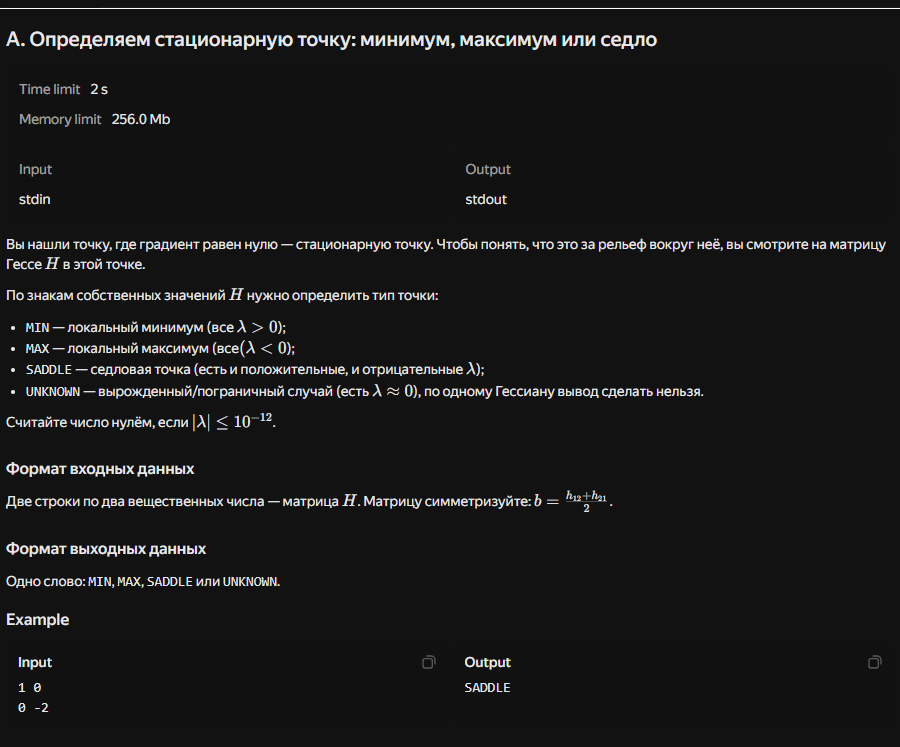

In [3]:
import math

# Наша основная функция
def classify_point(h11, h12, h21, h22):
    b = (h12 + h21) / 2.0
    B = -(h11 + h22)
    C = h11 * h22 - b * b
    
    D = B**2 - 4 * C
    if D < 0:
        D = 0
        
    lambda1 = (-B + math.sqrt(D)) / 2.0
    lambda2 = (-B - math.sqrt(D)) / 2.0
    
    eps = 1e-12
    if abs(lambda1) <= eps or abs(lambda2) <= eps:
        result = "UNKNOWN"
    elif lambda1 > eps and lambda2 > eps:
        result = "MIN"
    elif lambda1 < -eps and lambda2 < -eps:
        result = "MAX"
    else:
        result = "SADDLE"
        
    # Возвращаем не только ответ, но и сами корни, чтобы на них посмотреть
    return result, lambda1, lambda2

# ==========================================
# БЛОК ТЕСТИРОВАНИЯ
# ==========================================
test_cases = [
    (1, 0, 0, -2, "Пример из задачи (Седло)"),
    (2, 0, 0, 3,  "Оба корня положительные (Дно ямы)"),
    (-2, 0, 0, -5, "Оба корня отрицательные (Вершина холма)"),
    (1, 0, 0, 0,  "Один из корней равен нулю (Вырожденный случай)"),
    (0, 5, -5, 0,  "Симметризация (b=0), корни будут нулями")
]

print(f"{'Матрица':<15} | {'λ1':<6} | {'λ2':<6} | {'Результат':<8} | {'Описание'}")
print("-" * 80)

for h11, h12, h21, h22, desc in test_cases:
    res, l1, l2 = classify_point(h11, h12, h21, h22)
    matrix_str = f"[{h11}, {h12}] [{h21}, {h22}]"
    
    # Печатаем красивую таблицу в консоль
    print(f"{matrix_str:<15} | {l1:>6.1f} | {l2:>6.1f} | {res:<8} | {desc}")

Матрица         | λ1     | λ2     | Результат | Описание
--------------------------------------------------------------------------------
[1, 0] [0, -2]  |    1.0 |   -2.0 | SADDLE   | Пример из задачи (Седло)
[2, 0] [0, 3]   |    3.0 |    2.0 | MIN      | Оба корня положительные (Дно ямы)
[-2, 0] [0, -5] |   -2.0 |   -5.0 | MAX      | Оба корня отрицательные (Вершина холма)
[1, 0] [0, 0]   |    1.0 |    0.0 | UNKNOWN  | Один из корней равен нулю (Вырожденный случай)
[0, 5] [-5, 0]  |    0.0 |    0.0 | UNKNOWN  | Симметризация (b=0), корни будут нулями


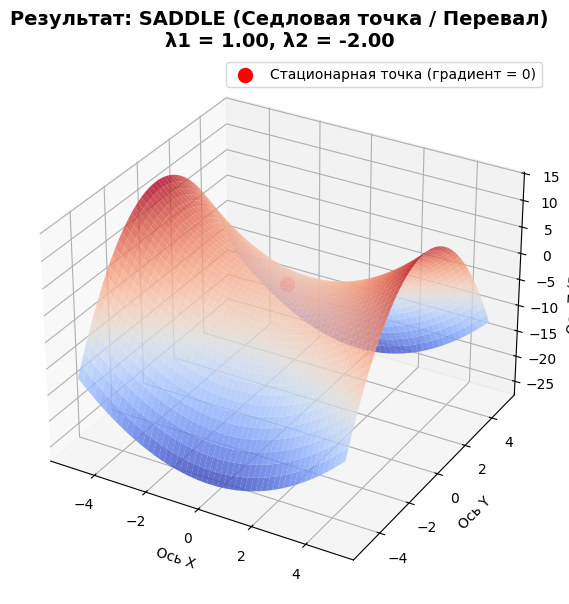

In [4]:
import math
import numpy as np
import matplotlib.pyplot as plt

def analyze_and_plot(h11, h12, h21, h22):
    # --- 1. МАТЕМАТИКА И ЛОГИКА ---
    b = (h12 + h21) / 2.0
    B = -(h11 + h22)
    C = h11 * h22 - b * b
    
    D = B**2 - 4 * C
    if D < 0: D = 0
        
    lambda1 = (-B + math.sqrt(D)) / 2.0
    lambda2 = (-B - math.sqrt(D)) / 2.0
    
    eps = 1e-12
    if abs(lambda1) <= eps or abs(lambda2) <= eps:
        result = "UNKNOWN (Вырожденный случай)"
    elif lambda1 > eps and lambda2 > eps:
        result = "MIN (Локальный минимум / Яма)"
    elif lambda1 < -eps and lambda2 < -eps:
        result = "MAX (Локальный максимум / Вершина)"
    else:
        result = "SADDLE (Седловая точка / Перевал)"
        
    # --- 2. ВИЗУАЛИЗАЦИЯ (3D ГРАФИК) ---
    # Создаем сетку координат от -5 до 5
    x = np.linspace(-5, 5, 50)
    y = np.linspace(-5, 5, 50)
    X, Y = np.meshgrid(x, y)
    
    # Вычисляем высоту Z (рельеф) по формуле квадратичной формы Гессиана
    Z = 0.5 * (h11 * X**2 + 2 * b * X * Y + h22 * Y**2)
    
    # Настраиваем 3D график
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    
    # Рисуем саму поверхность (cmap='coolwarm' сделает ямы синими, а горы красными)
    surf = ax.plot_surface(X, Y, Z, cmap='coolwarm', alpha=0.8, edgecolor='none')
    
    # Рисуем нашу стационарную точку в центре (0,0,0) большим красным шариком
    ax.scatter(0, 0, 0, color='red', s=100, label='Стационарная точка (градиент = 0)')
    
    # Оформляем надписи
    title_text = f"Результат: {result}\nλ1 = {lambda1:.2f}, λ2 = {lambda2:.2f}"
    ax.set_title(title_text, fontsize=14, fontweight='bold')
    ax.set_xlabel('Ось X')
    ax.set_ylabel('Ось Y')
    ax.set_zlabel('Ось Z (Высота)')
    ax.legend()
    
    # Показываем график
    plt.show()

# ==========================================
# ЗАПУСК (Раскомментируй нужный пример, убрав символ # в начале строки)
# ==========================================

# Пример 1: Седло (из твоей задачи)
analyze_and_plot(1, 0, 0, -2)

# Пример 2: Локальный минимум (Дно ямы, раскомментируй строку ниже чтобы увидеть)
# analyze_and_plot(2, 0, 0, 2)

# Пример 3: Локальный максимум (Вершина горы)
# analyze_and_plot(-2, 0, 0, -2)

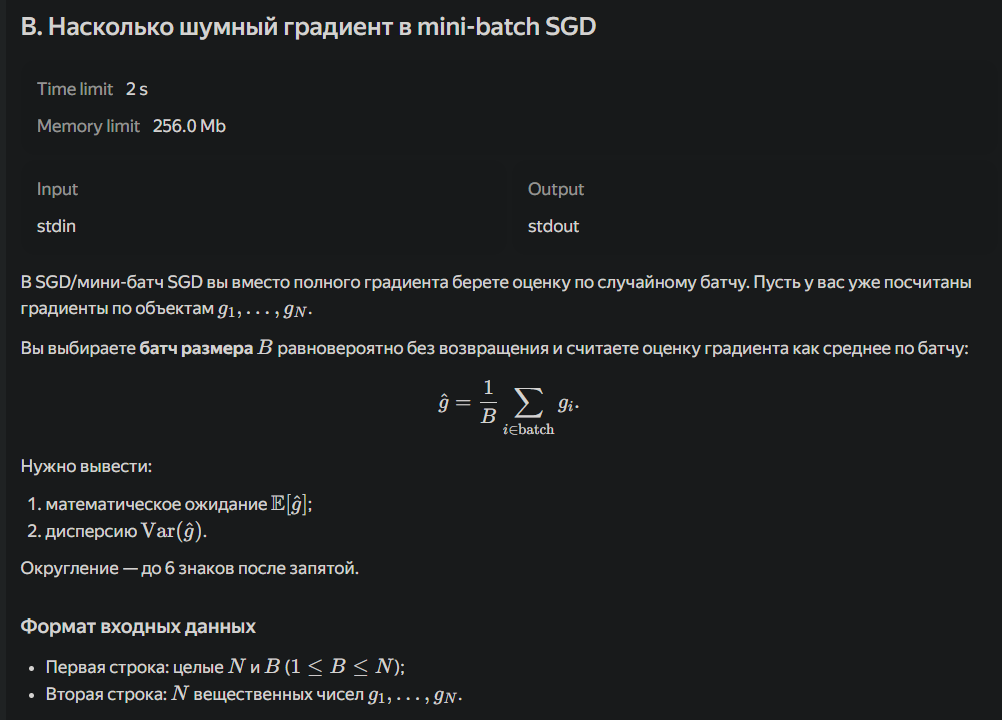
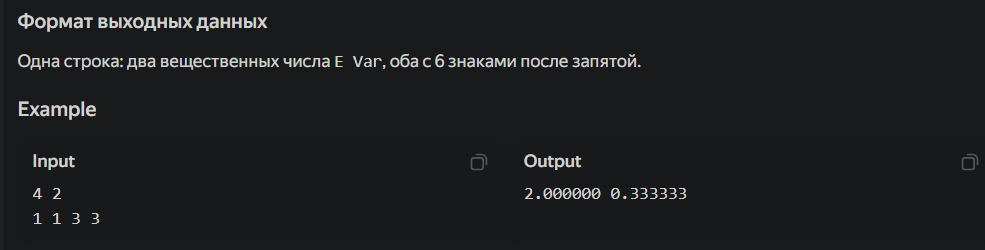

In [5]:
N = 4
B = 2
g = [1, 1, 3, 3]

# 1. Считаем математическое ожидание (E)
sum_g = 0
for val in g:
    sum_g += val
    
E = sum_g / N

# 2. Считаем базовую дисперсию (sigma_sq)
sum_sq_diff = 0
for val in g:
    sum_sq_diff += (val - E)**2
    
sigma_sq = sum_sq_diff / N

# 3. Считаем итоговую дисперсию батча (Var)
Var = (sigma_sq / B) * ((N - B) / (N - 1))

print(E, Var)

2.0 0.3333333333333333


In [6]:
import sys

def main():
    # 1. Считываем все данные разом
    data = sys.stdin.read().split()
    if not data:
        return
        
    N = int(data[0])
    B = int(data[1])
    
    # Считываем оставшиеся N чисел в список g (сразу превращая их в float)
    g = [float(x) for x in data[2:2+N]]
    
    # 2. Считаем математическое ожидание (E)
    E = sum(g) / N
    
    # 3. Считаем дисперсию (Var)
    sigma_sq = sum((val - E)**2 for val in g) / N
    Var = (sigma_sq / B) * ((N - B) / (N - 1))
    
    # 4. Выводим результат строго с 6 знаками после запятой
    print(f"{E:.6f} {Var:.6f}")

if __name__ == '__main__':
    main()